Columns: ['amfi_code', 'date', 'nav']


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692



Selected funds:
- 119551
- 100016
- 119095
- 149324
- 101206
- 101207
- 119120
- 101208
- 119094
- 102885

Correlation Matrix:


amfi_code,100016,101206,101207,101208,102885,119094,119095,119120,119551,149324
amfi_code,,,,,,,,,,
100016,1.000000,0.027747,0.016053,-0.033773,-0.093533,-0.067744,-0.038406,-0.022521,0.040858,0.028672
101206,0.027747,1.000000,0.010202,-0.027230,0.001570,-0.040309,-0.029799,0.035566,-0.025373,-0.004785
101207,0.016053,0.010202,1.000000,-0.007530,-0.005929,0.017462,-0.029528,0.035107,0.011505,-0.006471
101208,-0.033773,-0.027230,-0.007530,1.000000,-0.001436,0.010877,0.039690,-0.015536,-0.004377,-0.010105
102885,-0.093533,0.001570,-0.005929,-0.001436,1.000000,0.037873,-0.039724,-0.047944,0.071103,0.002378
119094,-0.067744,-0.040309,0.017462,0.010877,0.037873,1.000000,-0.011836,0.017299,0.015722,-0.017765
119095,-0.038406,-0.029799,-0.029528,0.039690,-0.039724,-0.011836,1.000000,-0.001612,0.000211,-0.000828
119120,-0.022521,0.035566,0.035107,-0.015536,-0.047944,0.017299,-0.001612,1.000000,0.021601,0.011987
119551,0.040858,-0.025373,0.011505,-0.004377,0.071103,0.015722,0.000211,0.021601,1.000000,-0.051753


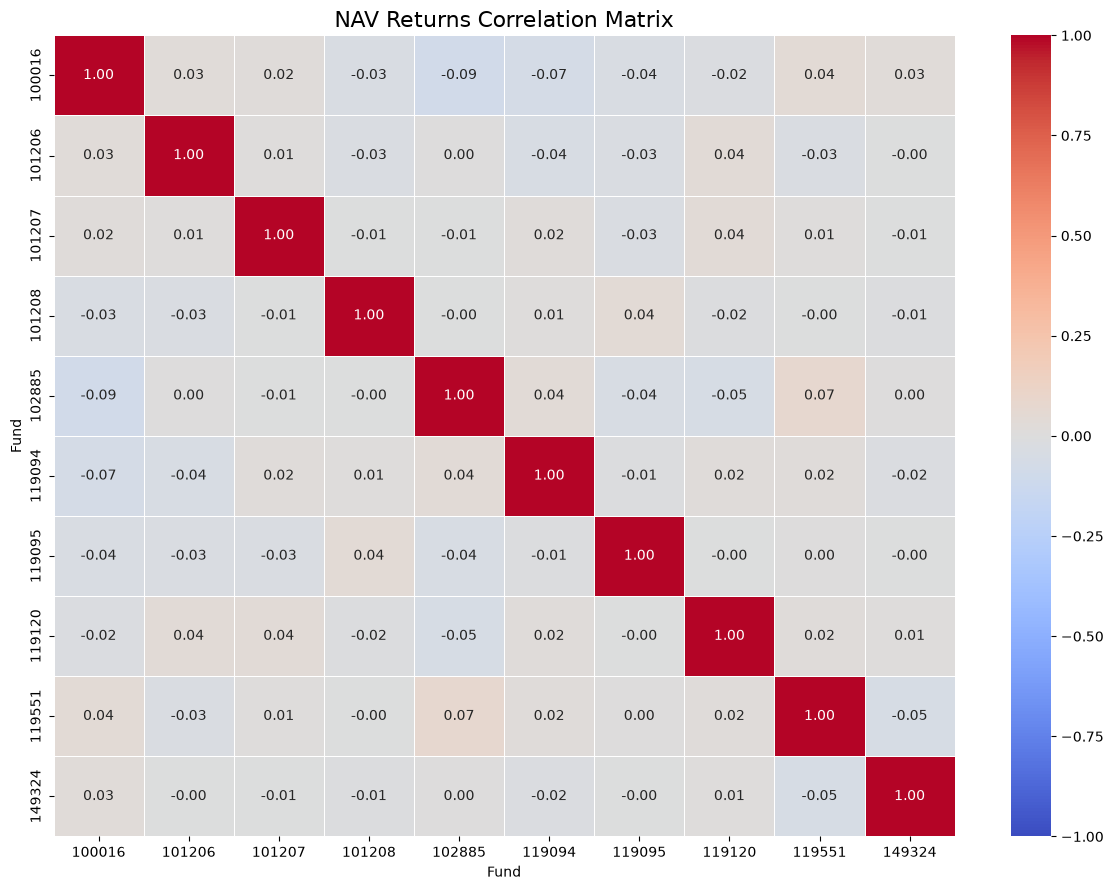


Task 8 completed successfully.
Correlation matrix saved to:
Reports/Correlation_Matrix.png


In [2]:

# DAY 3 - TASK 8: CORRELATION MATRIX

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading NAV history:
df = pd.read_csv("../Data/Raw/02_nav_history.csv")

# Cleaning column names:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Columns:", df.columns.tolist())
display(df.head())


# Identify important columns

date_col = next(
    col for col in df.columns
    if "date" in col
)

nav_col = next(
    col for col in df.columns
    if "nav" in col
)

fund_col = "amfi_code"

# Converting values:
df[date_col] = pd.to_datetime(
    df[date_col],
    errors="coerce"
)

df[nav_col] = pd.to_numeric(
    df[nav_col],
    errors="coerce"
)

# Removing invalid rows:
df = df.dropna(
    subset=[date_col, nav_col, fund_col]
)

# Sort data:
df = df.sort_values(date_col)


# Select 10 funds

selected_funds = (
    df[fund_col]
    .drop_duplicates()
    .head(10)
    .tolist()
)

print("\nSelected funds:")
for fund in selected_funds:
    print("-", fund)

# Keeping selected funds:
selected_df = df[
    df[fund_col].isin(selected_funds)
].copy()


# Converting NAV data into wide format:

nav_table = selected_df.pivot_table(
    index=date_col,
    columns=fund_col,
    values=nav_col,
    aggfunc="last"
)


# Calculating daily NAV returns:


returns = nav_table.pct_change()

# Removing rows where all returns are missing:
returns = returns.dropna(how="all")

# Calculating correlation matrix:


correlation_matrix = returns.corr()

print("\nCorrelation Matrix:")
display(correlation_matrix)


# Creating heatmap:

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5
)

plt.title(
    "NAV Returns Correlation Matrix",
    fontsize=16
)

plt.xlabel("Fund")
plt.ylabel("Fund")

plt.tight_layout()

# Save chart:

plt.savefig(
    "../Reports/Correlation_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nTask 8 completed successfully.")
print("Correlation matrix saved to:")
print("Reports/Correlation_Matrix.png")